Loading data...


<ipython-input-1-f4bf6e65566f>:13: DtypeWarning: Columns (43,51,52,57) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(TRAIN_PATH)
<ipython-input-1-f4bf6e65566f>:14: DtypeWarning: Columns (42,50,51,56) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(TEST_PATH)


Train period: 201901 ~ 202207
Test period : 202301 ~ 202307


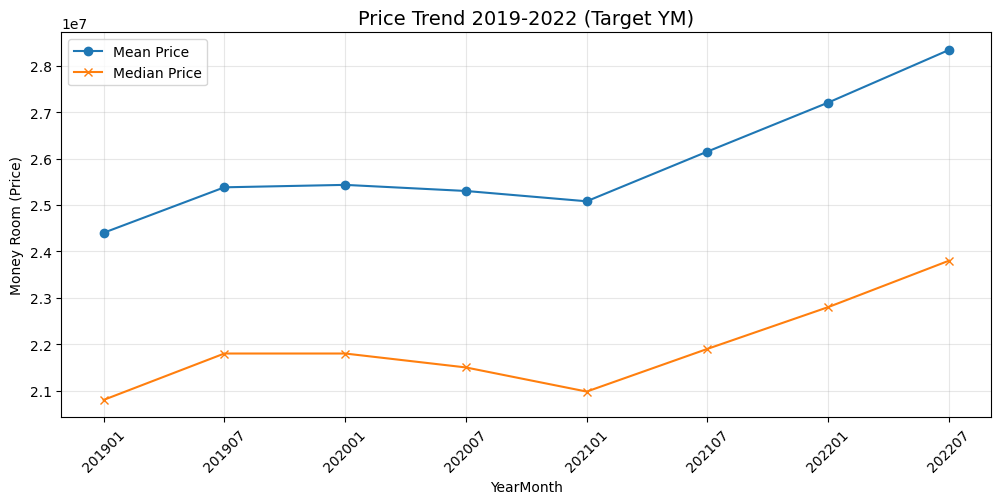

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


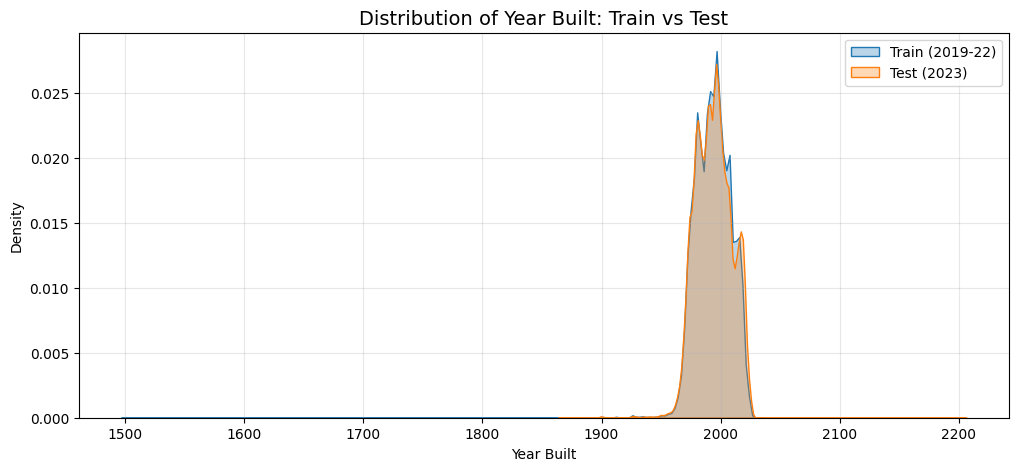

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19990 (\N{CJK UNIFIED IDEOGRAPH-4E16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30000 (\N{CJK UNIFIED IDEOGRAPH-7530}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35895 (\N{CJK UNIFIED IDEOGRAPH-8C37}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36275 (\N{CJK UNIFIED IDEOGRAPH-8DB3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

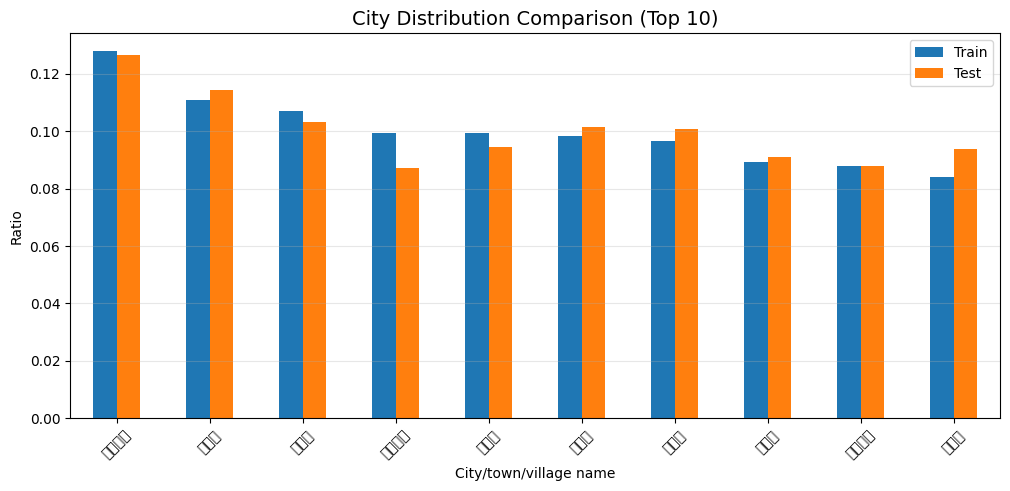

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

def run_time_series_eda():
    print("Loading data...")
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    # target_ym を datetime型など扱いやすい形に変換
    # format: YYYYMM -> str -> create date
    # 今回は単純に int のままソート用に使います
    
    print(f"Train period: {train_df['target_ym'].min()} ~ {train_df['target_ym'].max()}")
    print(f"Test period : {test_df['target_ym'].min()} ~ {test_df['target_ym'].max()}")
    
    # -------------------------------------------------------
    # 1. 価格の時系列トレンド (Trainのみ)
    # -------------------------------------------------------
    # 外れ値の影響を抑えるため、平均だけでなく中央値も見る
    trend_stats = train_df.groupby('target_ym')['money_room'].agg(['mean', 'median', 'count']).reset_index()
    
    plt.figure(figsize=(12, 5))
    plt.plot(trend_stats['target_ym'].astype(str), trend_stats['mean'], marker='o', label='Mean Price')
    plt.plot(trend_stats['target_ym'].astype(str), trend_stats['median'], marker='x', label='Median Price')
    plt.title('Price Trend 2019-2022 (Target YM)', fontsize=14)
    plt.xlabel('YearMonth')
    plt.ylabel('Money Room (Price)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # -------------------------------------------------------
    # 2. Train vs Test の分布比較 (Adversarial Validationの観点)
    # -------------------------------------------------------
    # 特に「築年数(year_built)」と「広さ(unit_areaなどは結合前でないと見にくいかもですが)」
    # ここでは確実に存在する 'year_built' を見ます
    
    plt.figure(figsize=(12, 5))
    
    # Train
    sns.kdeplot(train_df['year_built'].dropna(), label='Train (2019-22)', fill=True, alpha=0.3)
    # Test
    sns.kdeplot(test_df['year_built'].dropna(), label='Test (2023)', fill=True, alpha=0.3)
    
    plt.title('Distribution of Year Built: Train vs Test', fontsize=14)
    plt.xlabel('Year Built')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # -------------------------------------------------------
    # 3. 市区町村ごとのデータ数の変化（上位10都市）
    # -------------------------------------------------------
    # Testデータで急に増えた都市、減った都市がないか？
    top_cities = train_df['City/town/village name'].value_counts().head(10).index
    
    train_counts = train_df[train_df['City/town/village name'].isin(top_cities)]['City/town/village name'].value_counts(normalize=True)
    test_counts = test_df[test_df['City/town/village name'].isin(top_cities)]['City/town/village name'].value_counts(normalize=True)
    
    df_compare = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).sort_values('Train', ascending=False)
    
    df_compare.plot(kind='bar', figsize=(12, 5))
    plt.title('City Distribution Comparison (Top 10)', fontsize=14)
    plt.ylabel('Ratio')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_time_series_eda()

<ipython-input-2-b1eb210b7a7d>:20: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(f"{OUTPUT_DIR}/train/train.csv")
<ipython-input-2-b1eb210b7a7d>:21: DtypeWarning: Columns (46,55,56,63,146) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(f"{OUTPUT_DIR}/test/test.csv")
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3

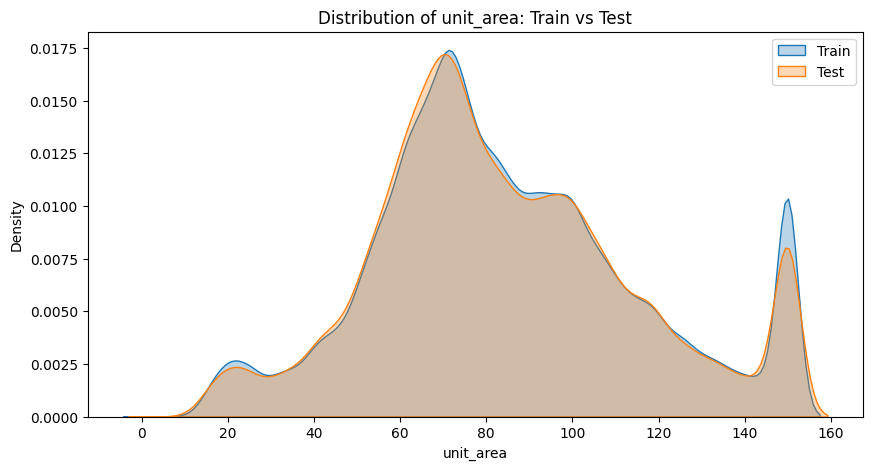

In [2]:
def check_area_distribution(train_df, test_df):
    plt.figure(figsize=(10, 5))
    
    # 外れ値を除外して見やすくする（0〜150平米くらいに絞る）
    # unit_area が存在するか確認し、なければ total_floor_area などで代用
    target_col = 'unit_area' if 'unit_area' in train_df.columns else 'total_floor_area'
    
    if target_col in train_df.columns:
        sns.kdeplot(train_df[target_col].clip(0, 150), label='Train', fill=True, alpha=0.3)
        sns.kdeplot(test_df[target_col].clip(0, 150), label='Test', fill=True, alpha=0.3)
        plt.title(f'Distribution of {target_col}: Train vs Test')
        plt.legend()
        plt.show()
    else:
        print(f"Column '{target_col}' not found.")

# 実行
# (データ読み込み済みの状態で実行してください)

train_df = pd.read_csv(f"{OUTPUT_DIR}/train/train.csv")
test_df = pd.read_csv(f"{OUTPUT_DIR}/test/test.csv")
check_area_distribution(train_df, test_df)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
OUTPUT_DIR = "/work/Real_estate"
train_df = pd.read_csv(f"{OUTPUT_DIR}/train/train.csv")
test_df = pd.read_csv(f"{OUTPUT_DIR}/test/test.csv")
train_df["madori_kind_all"].head()

<ipython-input-4-e07c67de5e30>:6: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(f"{OUTPUT_DIR}/train/train.csv")
<ipython-input-4-e07c67de5e30>:7: DtypeWarning: Columns (46,55,56,63,146) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(f"{OUTPUT_DIR}/test/test.csv")


0    50
1    50
2    50
3    50
4    50
Name: madori_kind_all, dtype: int64